
# Final Python Notebook 3: Regression DT and Ensemble Learners
## Machine Learning & Data Mining Coursework

**Author:** Sudam Pabasara Wijerathna
**Student ID:** w2120678  
**Module:** 5DATA002W.2  
**University:** University of Westminster



---

### This notebook covers:

**CASE STUDY (A) – Task (5f):** Loan Approval Status Ensemble Classifier with TWO base learners  
**CASE STUDY (B):** Predicting Maximum Loan Amount  
- **Task (1)** – Domain Understanding and Designing Your Regression Experiments  
- **Task (2)** – Modelling: Build Predictive Regression Models (DT-1 and DT-2)  
- **Task (3)** – Evaluating Maximum Loan Amount DT Regression Models



## Initialization: Import Libraries and Load Data

> **Code Reuse Session 3 (Week 9):** Leveraged code blocks for installing dependencies, importing regression and ensemble libraries, and loading the dataset.


In [134]:
import subprocess
import sys

# Install required packages
packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'joblib']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("✓ All dependencies ready!")

✓ All dependencies ready!



> **Code Reuse Session 3 (Week 9):** Leveraged code block for importing all required libraries for both ensemble classification and regression decision tree modelling.



> **Code Reuse Session 3 (Week 9):** Leveraged code block for loading the raw CSV dataset for both ensemble and regression tasks.


In [135]:

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Regression imports
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Classification / Ensemble imports
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ All libraries imported successfully")


✓ All libraries imported successfully


In [136]:

# Load the raw dataset directly
df_full = pd.read_csv('../loan_approval_data.csv')

print("✓ Data loaded from CSV")
print(f"  Dataset shape: {df_full.shape}")
print(f"  Columns: {list(df_full.columns)}")


✓ Data loaded from CSV
  Dataset shape: (58645, 13)
  Columns: ['id', 'age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']



---

## CASE STUDY (A) – Task (5f): Ensemble Classifier

Combine TWO out of THREE base learners (NB, LR, KNN) into a probability-based voting ensemble classifier for Loan Approval Status prediction.

> **Code Reuse Session 3 (Week 9):** Leveraged code blocks for preparing classification data, building base learners, creating a voting ensemble, and evaluating with confusion matrices, ROC curves and classification reports.


In [137]:

# Prepare classification data from raw CSV (same pipeline as Notebook 2)
df_clf = df_full.copy()

# Impute categorical NaNs with mode
for col in df_clf.select_dtypes(include=['object']).columns:
    df_clf[col] = df_clf[col].fillna(df_clf[col].mode()[0])

# Impute numerical NaNs with mean
for col in df_clf.select_dtypes(include=[np.number]).columns:
    df_clf[col] = df_clf[col].fillna(df_clf[col].mean())

# Remove duplicates
df_clf.drop_duplicates(inplace=True)

# Separate features and target (same columns as Notebook 2)
X_approval = df_clf.drop(['id', 'loan_approval_status', 'max_allowed_loan',
                          'home_ownership', 'loan_intent', 'payment_default_on_file'], axis=1)
y_approval = df_clf['loan_approval_status']

# Train-test split with stratification (identical to Notebook 2)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_approval, y_approval,
    test_size=0.2,
    random_state=42,
    stratify=y_approval
)

# Handle remaining missing values and scale
imputer_clf = SimpleImputer(strategy='mean')
X_train_clf_imputed = pd.DataFrame(
    imputer_clf.fit_transform(X_train_clf),
    columns=X_train_clf.columns, index=X_train_clf.index
)
X_test_clf_imputed = pd.DataFrame(
    imputer_clf.transform(X_test_clf),
    columns=X_test_clf.columns, index=X_test_clf.index
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf_imputed)
X_test_clf_scaled = scaler_clf.transform(X_test_clf_imputed)

print("✓ Classification data prepared (same split as Notebook 2)")
print(f"  Features: {list(X_approval.columns)}")
print(f"  Training: {X_train_clf_scaled.shape[0]} | Testing: {X_test_clf_scaled.shape[0]}")


✓ Classification data prepared (same split as Notebook 2)
  Features: ['age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']
  Training: 46916 | Testing: 11729



> **Code Reuse Session 3 (Week 9):** Leveraged code block for training three base classifiers, selecting the TWO best, building a probability-based VotingClassifier, and evaluating ensemble performance.



> **Code Reuse Session 3 (Week 9):** Leveraged code block for plotting confusion matrices, ROC curves, and classification reports for both base learners and the voting ensemble.



> **Code Reuse Session 3 (Week 9):** Leveraged code block for comparing ensemble vs base learners performance using bar chart and metrics table.


In [138]:

# Build the TWO base learners for ensemble
print("=" * 80)
print("TASK (5f): BUILDING ENSEMBLE CLASSIFIER")
print("=" * 80)

# Train base learners (same as Notebook 2)
nb_clf = GaussianNB()
nb_clf.fit(X_train_clf_scaled, y_train_clf)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_clf_scaled, y_train_clf)

lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train_clf_scaled, y_train_clf)

# Evaluate base learners to select best TWO
base_results = []
base_models = {'Naive Bayes': nb_clf, 'Logistic Regression': lr_clf, 'K-Nearest Neighbours': knn_clf}

for name, model in base_models.items():
    y_pred_b = model.predict(X_test_clf_scaled)
    f1_b = f1_score(y_test_clf, y_pred_b, zero_division=0)
    base_results.append({'Model': name, 'F1-Score': f1_b})

base_df = pd.DataFrame(base_results).sort_values('F1-Score', ascending=False)
best_two_names = base_df.head(2)['Model'].values
print(f"\nBase Learners selected for Ensemble: {best_two_names[0]} & {best_two_names[1]}")

# Build probability-based voting ensemble
voting_clf = VotingClassifier(
    estimators=[
        ('model1', base_models[best_two_names[0]]),
        ('model2', base_models[best_two_names[1]])
    ],
    voting='soft'  # Probability-based voting
)
voting_clf.fit(X_train_clf_scaled, y_train_clf)

# Evaluate ensemble
y_pred_ensemble = voting_clf.predict(X_test_clf_scaled)
y_pred_proba_ensemble = voting_clf.predict_proba(X_test_clf_scaled)[:, 1]

acc_ens = accuracy_score(y_test_clf, y_pred_ensemble)
prec_ens = precision_score(y_test_clf, y_pred_ensemble, zero_division=0)
rec_ens = recall_score(y_test_clf, y_pred_ensemble, zero_division=0)
f1_ens = f1_score(y_test_clf, y_pred_ensemble)
roc_ens = roc_auc_score(y_test_clf, y_pred_proba_ensemble)

print(f"\nEnsemble Test Scores:")
print(f"  Accuracy:  {acc_ens:.4f}")
print(f"  Precision: {prec_ens:.4f}")
print(f"  Recall:    {rec_ens:.4f}")
print(f"  F1-Score:  {f1_ens:.4f}")
print(f"  ROC-AUC:   {roc_ens:.4f}")

print(f"\n✓ Ensemble classifier built and evaluated")


TASK (5f): BUILDING ENSEMBLE CLASSIFIER

Base Learners selected for Ensemble: K-Nearest Neighbours & Naive Bayes

Ensemble Test Scores:
  Accuracy:  0.8959
  Precision: 0.6710
  Recall:    0.5275
  F1-Score:  0.5907
  ROC-AUC:   0.8787

✓ Ensemble classifier built and evaluated


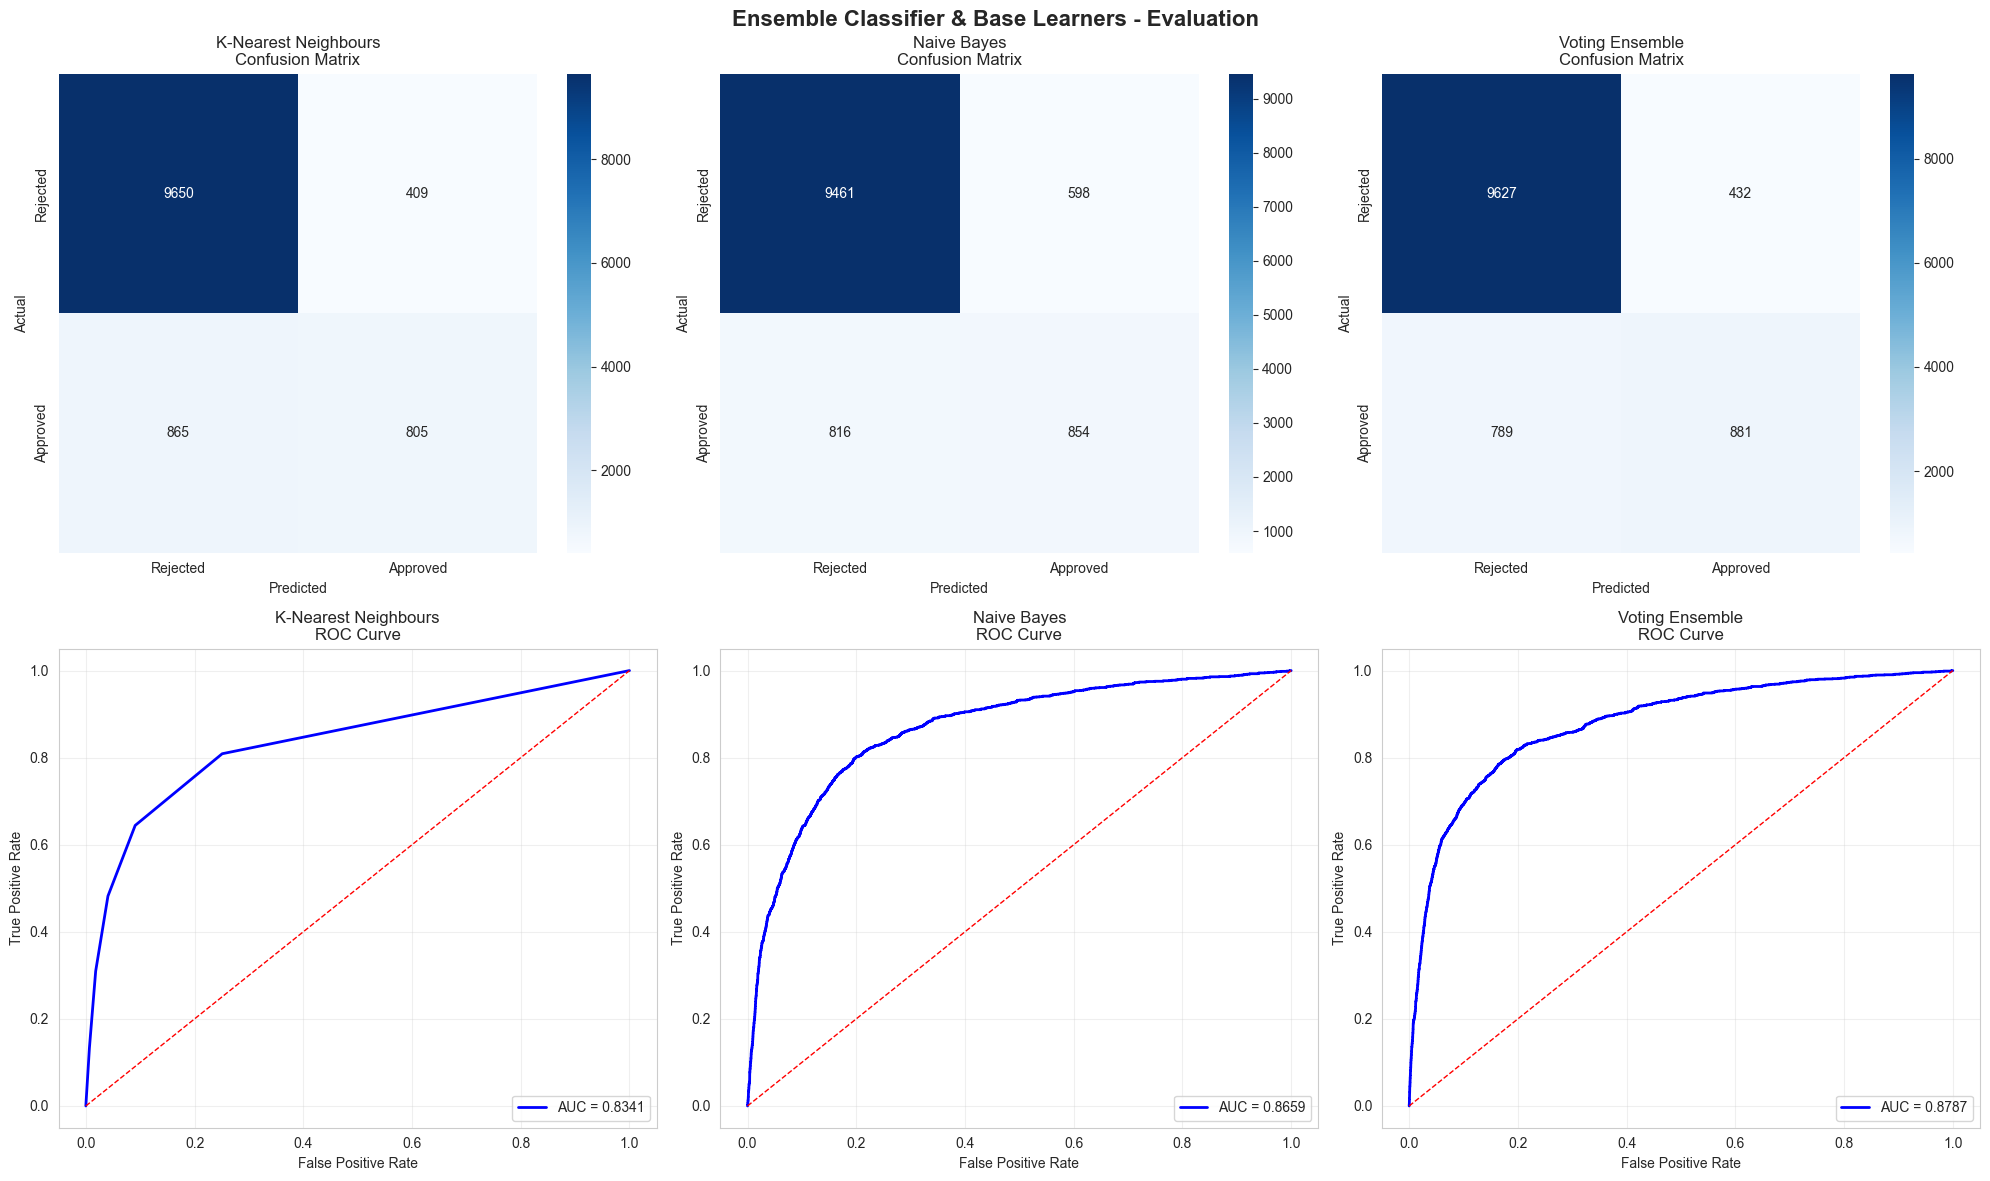


Classification Report: K-Nearest Neighbours
              precision    recall  f1-score   support

    Rejected       0.92      0.96      0.94     10059
    Approved       0.66      0.48      0.56      1670

    accuracy                           0.89     11729
   macro avg       0.79      0.72      0.75     11729
weighted avg       0.88      0.89      0.88     11729


Classification Report: Naive Bayes
              precision    recall  f1-score   support

    Rejected       0.92      0.94      0.93     10059
    Approved       0.59      0.51      0.55      1670

    accuracy                           0.88     11729
   macro avg       0.75      0.73      0.74     11729
weighted avg       0.87      0.88      0.88     11729


Classification Report: Voting Ensemble
              precision    recall  f1-score   support

    Rejected       0.92      0.96      0.94     10059
    Approved       0.67      0.53      0.59      1670

    accuracy                           0.90     11729
   macr

In [139]:

# Ensemble & Base Learners Visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Confusion Matrices for base learners + ensemble
all_models = {best_two_names[0]: base_models[best_two_names[0]],
              best_two_names[1]: base_models[best_two_names[1]],
              'Voting Ensemble': voting_clf}

for idx, (name, model) in enumerate(all_models.items()):
    y_pred_v = model.predict(X_test_clf_scaled)
    cm = confusion_matrix(y_test_clf, y_pred_v)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx],
                xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
    axes[0, idx].set_title(f'{name}\nConfusion Matrix', fontsize=12)
    axes[0, idx].set_xlabel('Predicted')
    axes[0, idx].set_ylabel('Actual')

# ROC Curves
for idx, (name, model) in enumerate(all_models.items()):
    y_proba_v = model.predict_proba(X_test_clf_scaled)[:, 1]
    fpr_v, tpr_v, _ = roc_curve(y_test_clf, y_proba_v)
    auc_v = auc(fpr_v, tpr_v)
    axes[1, idx].plot(fpr_v, tpr_v, 'b-', linewidth=2, label=f'AUC = {auc_v:.4f}')
    axes[1, idx].plot([0, 1], [0, 1], 'r--', linewidth=1)
    axes[1, idx].set_title(f'{name}\nROC Curve', fontsize=12)
    axes[1, idx].set_xlabel('False Positive Rate')
    axes[1, idx].set_ylabel('True Positive Rate')
    axes[1, idx].legend(loc='lower right')
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('Ensemble Classifier & Base Learners - Evaluation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification Reports
for name, model in all_models.items():
    y_pred_v = model.predict(X_test_clf_scaled)
    print(f"\n{'=' * 60}")
    print(f"Classification Report: {name}")
    print('=' * 60)
    print(classification_report(y_test_clf, y_pred_v, target_names=['Rejected', 'Approved']))


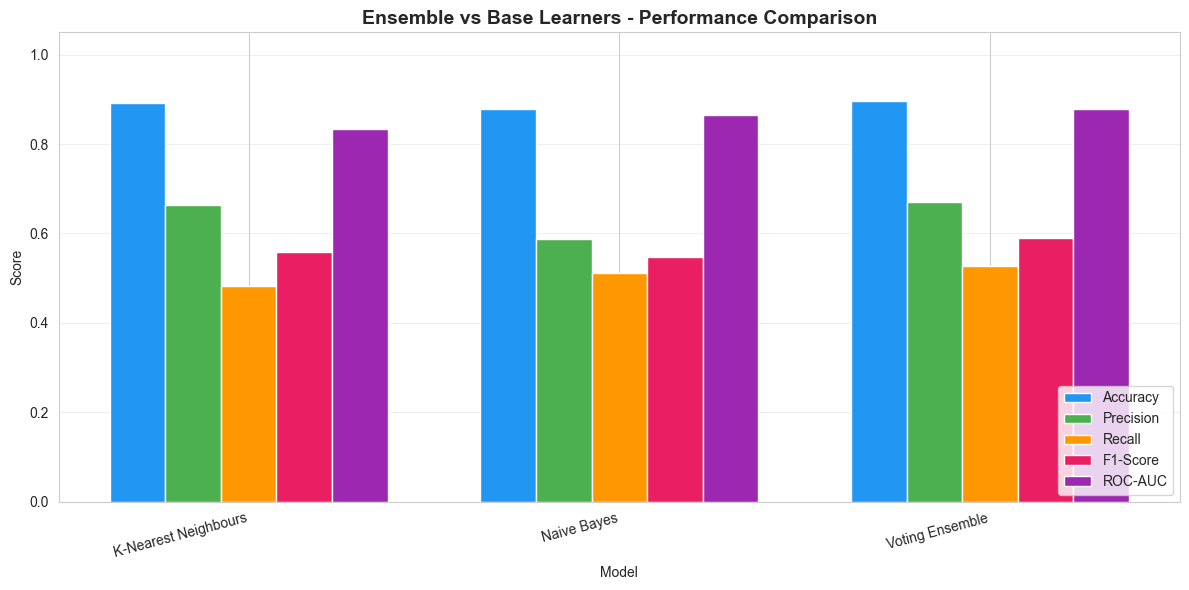


Comparison Table:
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
K-Nearest Neighbours    0.8914     0.6631  0.4820    0.5583   0.8341
         Naive Bayes    0.8794     0.5882  0.5114    0.5471   0.8659
     Voting Ensemble    0.8959     0.6710  0.5275    0.5907   0.8787

✓ Best model: Voting Ensemble (F1=0.5907)


In [140]:

# Ensemble vs Base Learners Comparison
comparison_data = []
for name, model in all_models.items():
    y_pred_c = model.predict(X_test_clf_scaled)
    y_proba_c = model.predict_proba(X_test_clf_scaled)[:, 1]
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_clf, y_pred_c),
        'Precision': precision_score(y_test_clf, y_pred_c, zero_division=0),
        'Recall': recall_score(y_test_clf, y_pred_c, zero_division=0),
        'F1-Score': f1_score(y_test_clf, y_pred_c, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_clf, y_proba_c)
    })

comp_df = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comp_df))
width = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, comp_df[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Ensemble vs Base Learners - Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(comp_df['Model'], rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nComparison Table:")
print(comp_df.to_string(index=False, float_format='%.4f'))
print(f"\n✓ Best model: Voting Ensemble (F1={comp_df[comp_df['Model']=='Voting Ensemble']['F1-Score'].values[0]:.4f})")



## Save Ensemble Models


In [141]:

# Save ensemble and base learner models
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(voting_clf, '../models/ensemble_clf.joblib')
joblib.dump(base_models[best_two_names[0]], f'../models/{best_two_names[0].replace(" ", "_")}_base.joblib')
joblib.dump(base_models[best_two_names[1]], f'../models/{best_two_names[1].replace(" ", "_")}_base.joblib')

print(f"✓ Saved Voting Ensemble to ../models/ensemble_clf.joblib")
print(f"✓ Saved {best_two_names[0]} base learner")
print(f"✓ Saved {best_two_names[1]} base learner")


✓ Saved Voting Ensemble to ../models/ensemble_clf.joblib
✓ Saved K-Nearest Neighbours base learner
✓ Saved Naive Bayes base learner



---

## CASE STUDY (B): PREDICTING MAXIMUM LOAN AMOUNT

**Research Question:** Does machine learning have the potential to assist bankers in predicting the Maximum Loan Amount offered to clients who were approved a loan?

## Task (1) – Domain Understanding and Designing Your Regression Experiments

The bankers decided that regression modelling is required to predict the Maximum Loan Amount for clients who are approved a loan. We use clients who have known `max_allowed_loan` values to build our regression models.

> **Code Reuse Session 3 (Week 9):** Leveraged code block for preparing the regression dataset — selecting clients with known max loan amounts, identifying retained features, and displaying dataset dimensions.


TASK (1): DOMAIN UNDERSTANDING - REGRESSION EXPERIMENTS

Total clients in dataset: 58645
Clients with known max_allowed_loan: 50292
Approved clients (for prediction): 8350

Retained Features for Regression Modeling:
  Features: ['age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']
  Feature Matrix Shape: (50292, 7)

Target Variable (max_allowed_loan) Statistics:
  Mean: $81,392.53
  Median: $69,431.50
  Min: $232.00
  Max: $2,638,778.00
  Std Dev: $58,121.45
  Unique Values: 22584


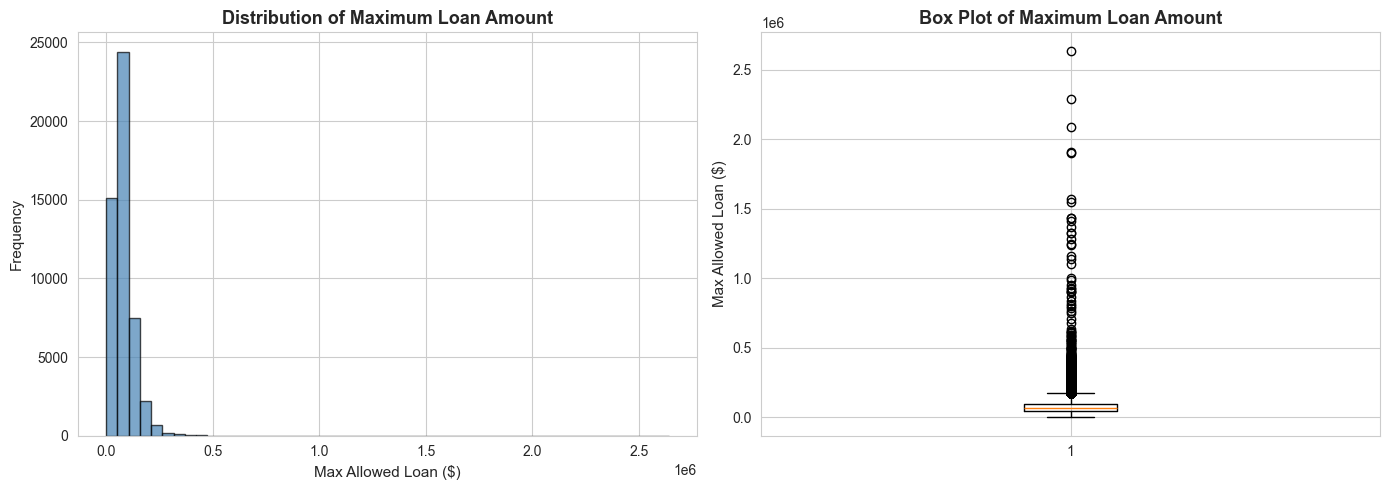


✓ Regression dataset prepared


In [142]:

print("=" * 80)
print("TASK (1): DOMAIN UNDERSTANDING - REGRESSION EXPERIMENTS")
print("=" * 80)

# Load raw data directly for regression analysis
df_raw = pd.read_csv('../loan_approval_data.csv')
print(f"\nTotal clients in dataset: {len(df_raw)}")

# For regression: use clients with known max_allowed_loan > 0
# These are clients where the bank determined a maximum loan amount
df_regression = df_raw[df_raw['max_allowed_loan'] > 0].copy()
print(f"Clients with known max_allowed_loan: {len(df_regression)}")

# Separate approved clients for final prediction
df_approved = df_raw[df_raw['loan_approval_status'] == 1].copy()
print(f"Approved clients (for prediction): {len(df_approved)}")

# Prepare features - drop non-predictive columns and categorical strings
# Keep only numeric features for regression
features_to_drop = ['id', 'loan_approval_status', 'max_allowed_loan', 
                     'home_ownership', 'loan_intent', 'payment_default_on_file']

X_lending = df_regression.drop(features_to_drop, axis=1)
y_lending = df_regression['max_allowed_loan']

print(f"\nRetained Features for Regression Modeling:")
print(f"  Features: {list(X_lending.columns)}")
print(f"  Feature Matrix Shape: {X_lending.shape}")
print(f"\nTarget Variable (max_allowed_loan) Statistics:")
print(f"  Mean: ${y_lending.mean():,.2f}")
print(f"  Median: ${y_lending.median():,.2f}")
print(f"  Min: ${y_lending.min():,.2f}")
print(f"  Max: ${y_lending.max():,.2f}")
print(f"  Std Dev: ${y_lending.std():,.2f}")
print(f"  Unique Values: {y_lending.nunique()}")

# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_lending, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Maximum Loan Amount', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Max Allowed Loan ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

axes[1].boxplot(y_lending, vert=True)
axes[1].set_title('Box Plot of Maximum Loan Amount', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Max Allowed Loan ($)', fontsize=11)

plt.tight_layout()
plt.savefig('../target_distribution_regression.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Regression dataset prepared")



---

## Task (2) – Modelling: Build Predictive Regression Models

**Part a)** Benefits of Decision Tree Regressors for this financial prediction problem  
**Part b)** Build DT-1 (fully grown) and DT-2 (pruned to FOUR levels)  
**Part c)** Visualize both decision trees with feature importance

> **Code Reuse Session 3 (Week 9):** Leveraged code blocks for building DecisionTreeRegressor models, tree visualization, and feature importance analysis.


In [143]:
print("\n" + "=" * 80)
print("TASK (2): REGRESSION MODELLING")
print("=" * 80)

print("\nPart a) Benefits of Decision Tree Regressors for Loan Amount Prediction:")
print("-" * 80)

benefits = [
    "1. Interpretability: White-box model shows decision logic transparent to stakeholders",
    "2. Non-linear relationships: Captures complex interactions without transformation",
    "3. No scaling required: Works directly with original feature scales",
    "4. Feature importance: Identifies most influential variables for lending decisions",
    "5. Single predictions: Provides specific loan amount recommendations per applicant",
    "6. Handles mixed types: Works with both continuous and categorical features naturally"
]

for benefit in benefits:
    print(f"  {benefit}")


TASK (2): REGRESSION MODELLING

Part a) Benefits of Decision Tree Regressors for Loan Amount Prediction:
--------------------------------------------------------------------------------
  1. Interpretability: White-box model shows decision logic transparent to stakeholders
  2. Non-linear relationships: Captures complex interactions without transformation
  3. No scaling required: Works directly with original feature scales
  4. Feature importance: Identifies most influential variables for lending decisions
  5. Single predictions: Provides specific loan amount recommendations per applicant
  6. Handles mixed types: Works with both continuous and categorical features naturally



> **Code Reuse Session 3 (Week 9):** Leveraged code block for train-test split and preparing regression data with SimpleImputer for missing values.



> **Code Reuse Session 3 (Week 9):** Leveraged code block for declaring and fitting DT-1 (fully grown DecisionTreeRegressor with no depth restriction).



> **Code Reuse Session 3 (Week 9):** Leveraged code block for declaring and fitting DT-2 (pre-pruned DecisionTreeRegressor with max_depth=4).



> **Code Reuse Session 3 (Week 9):** Leveraged code block for visualizing DT-1 (fully grown tree, showing top 3 levels) with plot_tree and feature importance bar chart.



> **Code Reuse Session 3 (Week 9):** Leveraged code block for visualizing DT-2 (full pruned tree with max_depth=4) and comparing feature importance between DT-1 and DT-2.


In [144]:

# Prepare data for regression
print("\nPart b) Building Decision Tree Regression Models:")
print("-" * 80)

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_lending, y_lending,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining set: {X_train_reg.shape[0]} samples")
print(f"Testing set: {X_test_reg.shape[0]} samples")

# Handle missing values
print(f"\nHandling missing values...")
imputer = SimpleImputer(strategy='mean')
X_train_reg = pd.DataFrame(
    imputer.fit_transform(X_train_reg),
    columns=X_train_reg.columns,
    index=X_train_reg.index
)
X_test_reg = pd.DataFrame(
    imputer.transform(X_test_reg),
    columns=X_test_reg.columns,
    index=X_test_reg.index
)
print(f"  ✓ Missing values handled with mean imputation")
print(f"  Training features shape: {X_train_reg.shape}")
print(f"  Testing features shape: {X_test_reg.shape}")



Part b) Building Decision Tree Regression Models:
--------------------------------------------------------------------------------

Training set: 40233 samples
Testing set: 10059 samples

Handling missing values...
  ✓ Missing values handled with mean imputation
  Training features shape: (40233, 7)
  Testing features shape: (10059, 7)


In [145]:
# Build DT-1: Fully grown Decision Tree
print("\nBuilding DT-1: Fully Grown Decision Tree Regressor...")

# Python code for DT-1
dt1_regressor = DecisionTreeRegressor(
    random_state=42
    # No max_depth restriction - fully grown
)
dt1_regressor.fit(X_train_reg, y_train_reg)

print(f"  ✓ DT-1 trained")
print(f"    Tree depth: {dt1_regressor.get_depth()}")
print(f"    Leaf nodes: {dt1_regressor.get_n_leaves()}")


Building DT-1: Fully Grown Decision Tree Regressor...
  ✓ DT-1 trained
    Tree depth: 24
    Leaf nodes: 22912


In [146]:
# Build DT-2: Pruned Decision Tree (max_depth=4)
print("\nBuilding DT-2: Pruned Decision Tree Regressor (max_depth=4)...")

# Python code for DT-2
dt2_regressor = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)
dt2_regressor.fit(X_train_reg, y_train_reg)

print(f"  ✓ DT-2 trained")
print(f"    Tree depth: {dt2_regressor.get_depth()}")
print(f"    Leaf nodes: {dt2_regressor.get_n_leaves()}")

print(f"\n  Pruning method: Pre-pruning using max_depth parameter")
print(f"  Benefits: Reduces complexity, prevents overfitting, improves interpretability")
print(f"  Disadvantages: May underfit if 4 levels insufficient for patterns")


Building DT-2: Pruned Decision Tree Regressor (max_depth=4)...
  ✓ DT-2 trained
    Tree depth: 4
    Leaf nodes: 16

  Pruning method: Pre-pruning using max_depth parameter
  Benefits: Reduces complexity, prevents overfitting, improves interpretability
  Disadvantages: May underfit if 4 levels insufficient for patterns



Part c) Visualizing Decision Trees:
--------------------------------------------------------------------------------

DT-1: FULLY GROWN DECISION TREE REGRESSOR

Tree Structure Information:
  • Tree Depth: 24
  • Number of Leaf Nodes: 22912
  • Total Number of Nodes: 45823

DT-1 Feature Importance:
              Feature  Importance
               income    0.885242
                  age    0.098913
    loan_income_ratio    0.009279
     emplyment_length    0.002772
credit_history_length    0.002476
          loan_amount    0.000967
   loan_interest_rate    0.000352


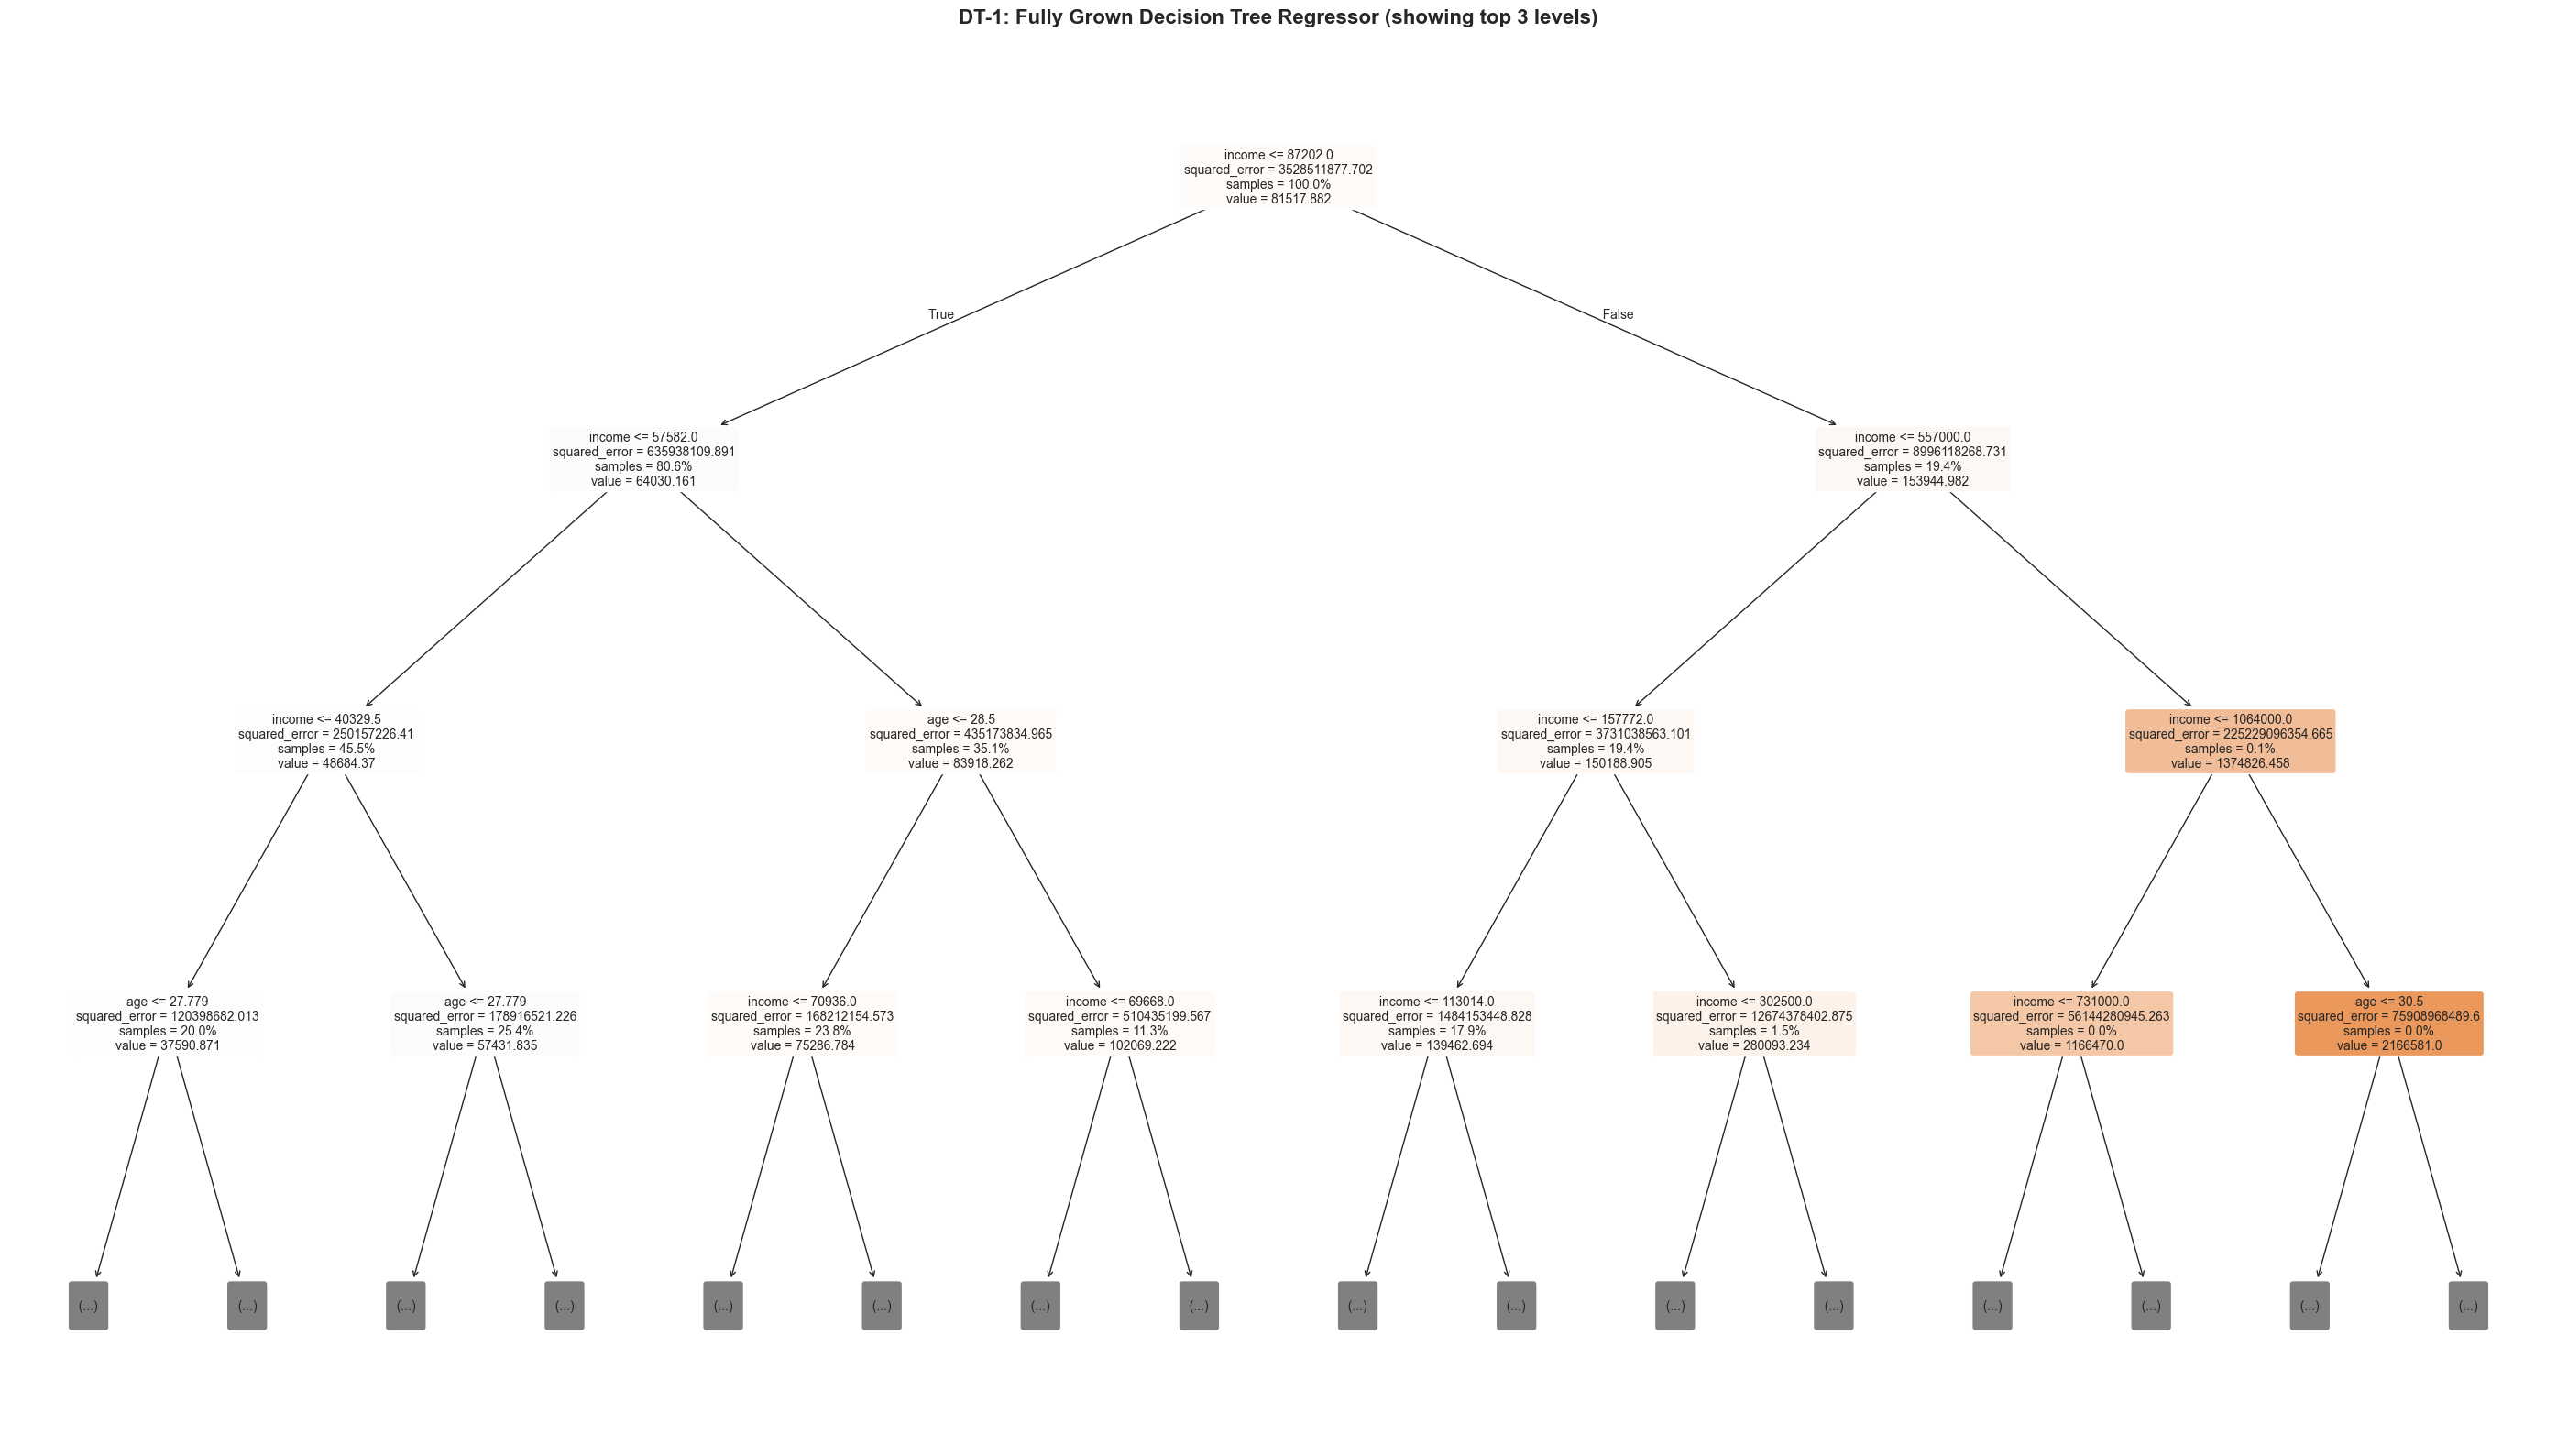


✓ DT-1 visualization saved


In [147]:

# Part c: Visualize Decision Trees
from sklearn.tree import export_text

print("\nPart c) Visualizing Decision Trees:")
print("-" * 80)

# ========== DT-1 Visualization ==========
print("\n" + "="*80)
print("DT-1: FULLY GROWN DECISION TREE REGRESSOR")
print("="*80)
print(f"\nTree Structure Information:")
print(f"  • Tree Depth: {dt1_regressor.get_depth()}")
print(f"  • Number of Leaf Nodes: {dt1_regressor.get_n_leaves()}")
print(f"  • Total Number of Nodes: {dt1_regressor.tree_.node_count}")

# Feature importance for DT-1
print(f"\nDT-1 Feature Importance:")
importance_df_dt1 = pd.DataFrame({
    'Feature': X_train_reg.columns,
    'Importance': dt1_regressor.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance_df_dt1.to_string(index=False))

# Visualize DT-1 (show max_depth=3 for readability if tree is deep)
display_depth = min(dt1_regressor.get_depth(), 4)
fig_height = max(8, display_depth * 4)
fig, ax = plt.subplots(figsize=(28, fig_height))
plot_tree(dt1_regressor, feature_names=list(X_train_reg.columns), 
          filled=True, rounded=True, ax=ax, fontsize=10, 
          max_depth=3, proportion=True)
ax.set_title('DT-1: Fully Grown Decision Tree Regressor (showing top 3 levels)', 
             fontsize=16, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../dt1_tree.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

print("\n✓ DT-1 visualization saved")



DT-2: PRUNED DECISION TREE REGRESSOR (max_depth=4)

Tree Structure Information:
  • Tree Depth: 4
  • Number of Leaf Nodes: 16
  • Total Number of Nodes: 31

DT-2 Feature Importance:
              Feature  Importance
               income    0.971614
                  age    0.026591
          loan_amount    0.001794
     emplyment_length    0.000000
   loan_interest_rate    0.000000
    loan_income_ratio    0.000000
credit_history_length    0.000000


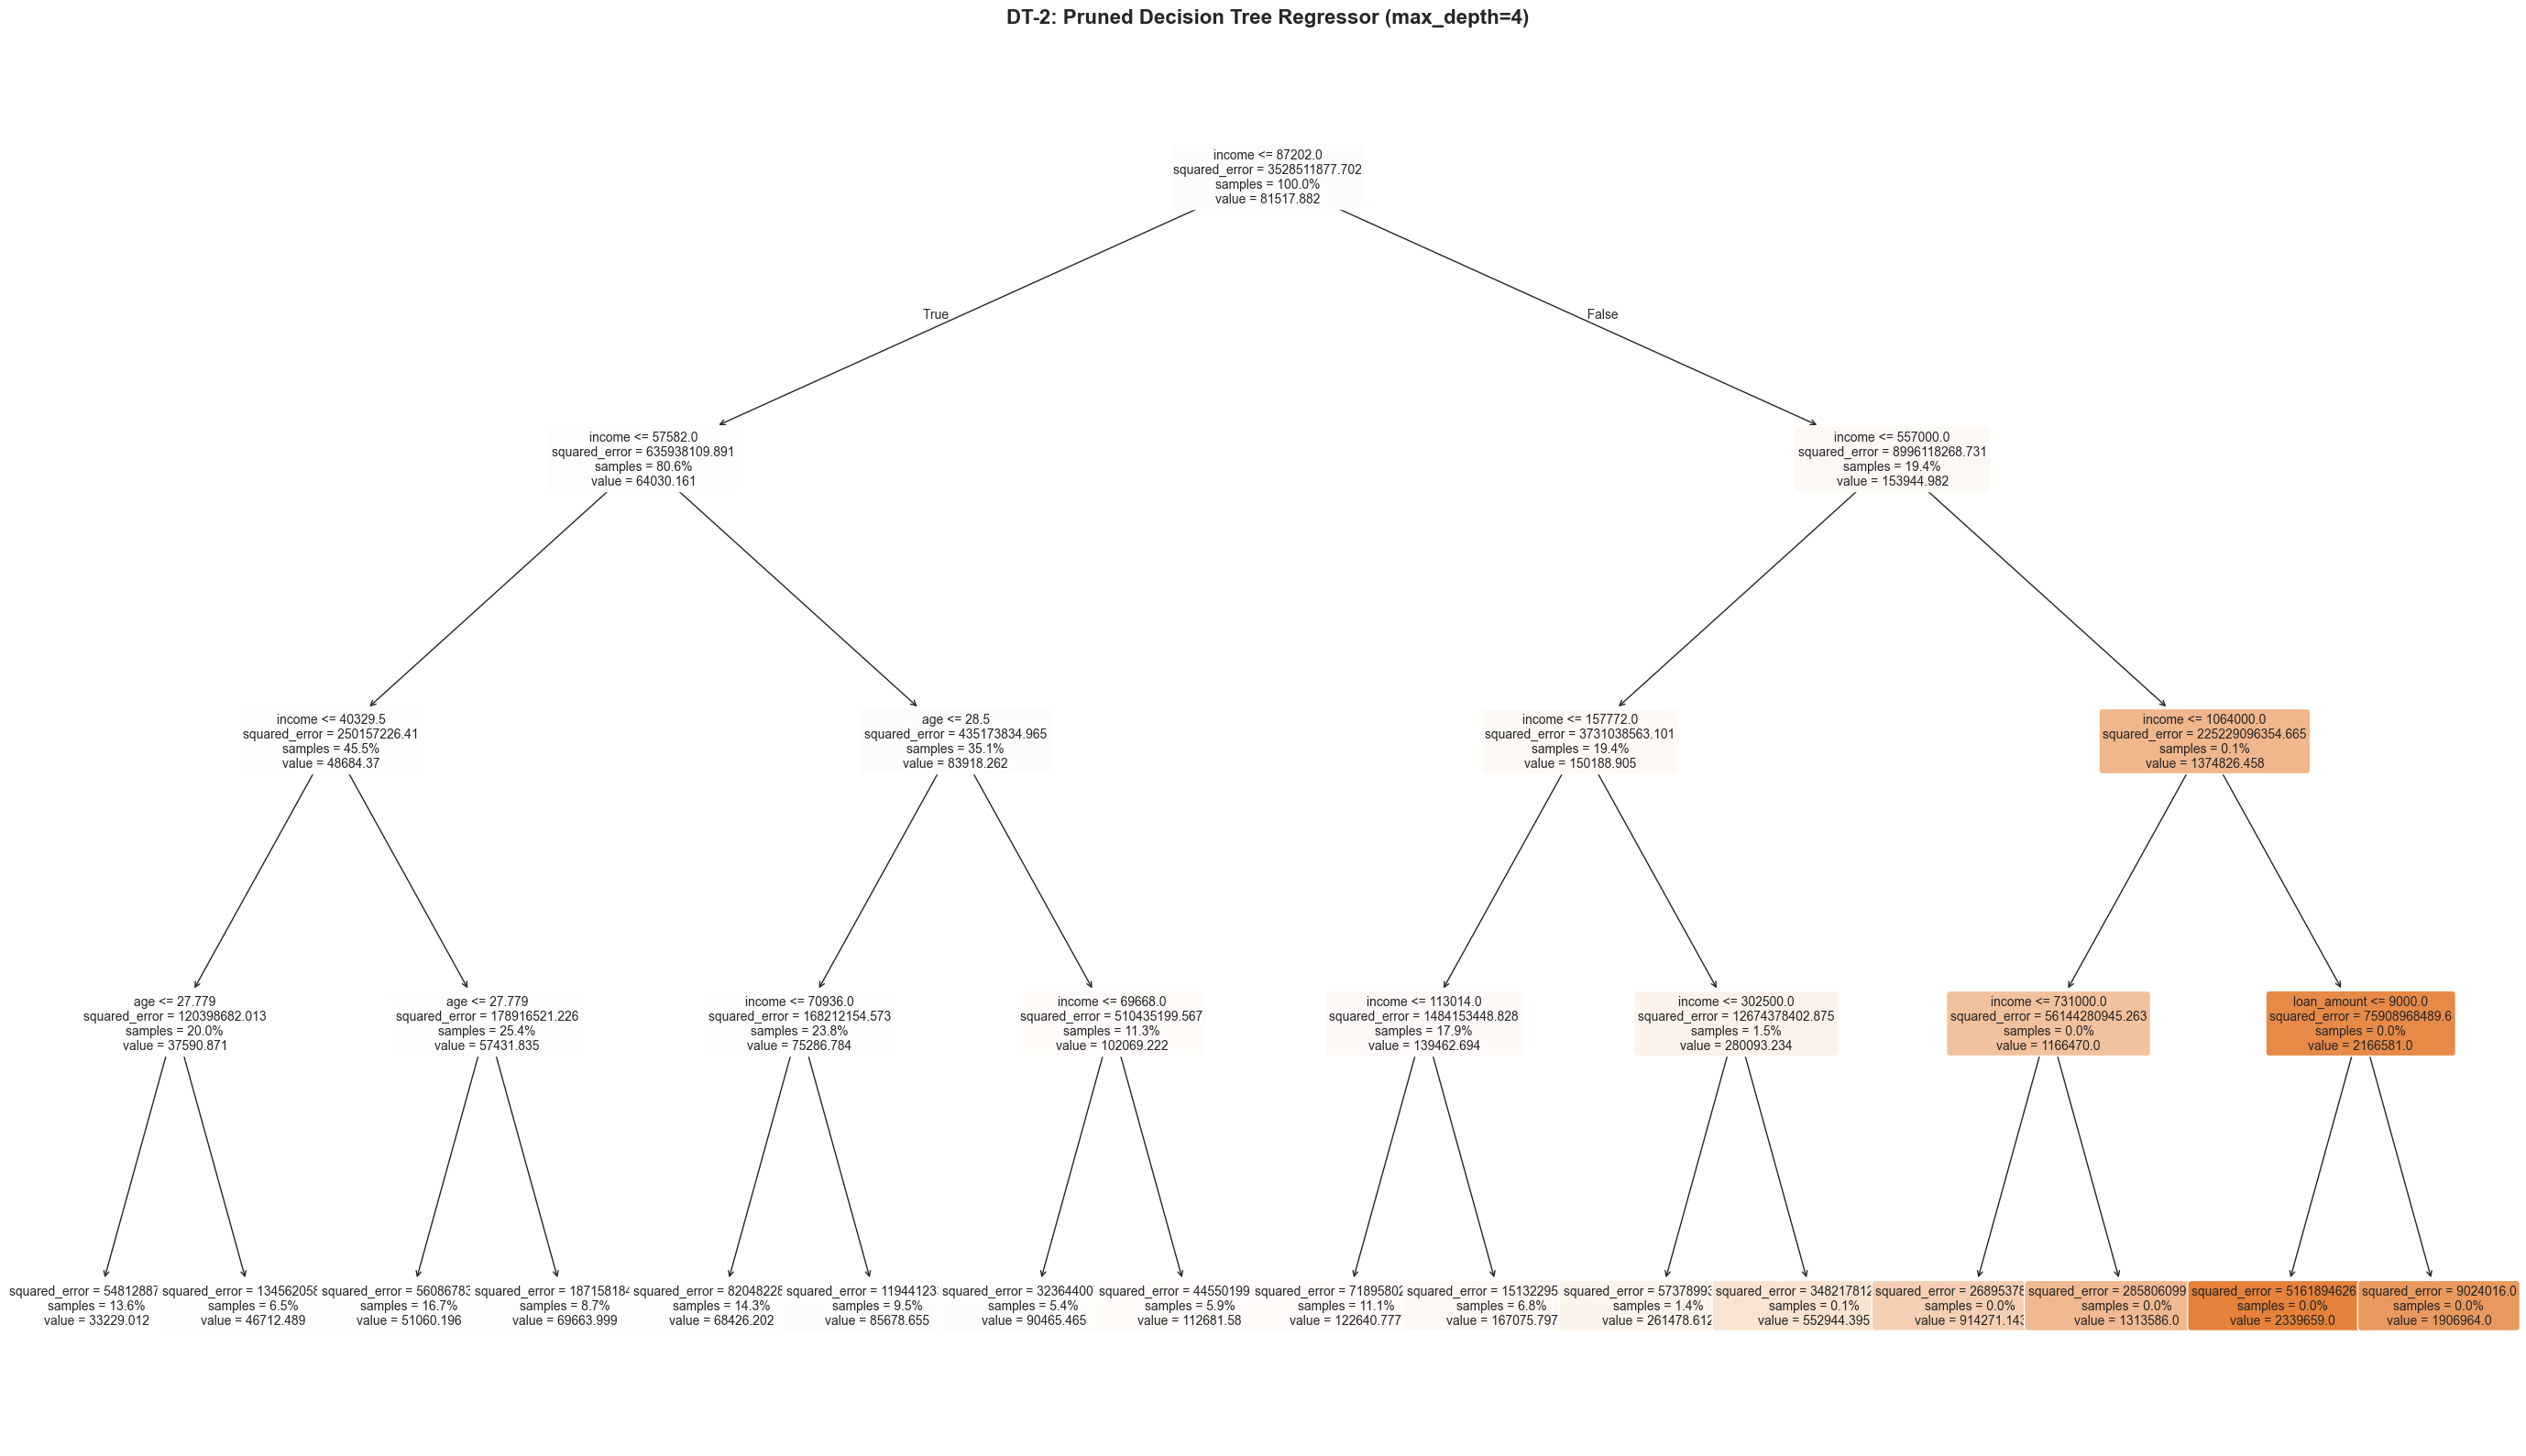

✓ DT-2 visualization saved


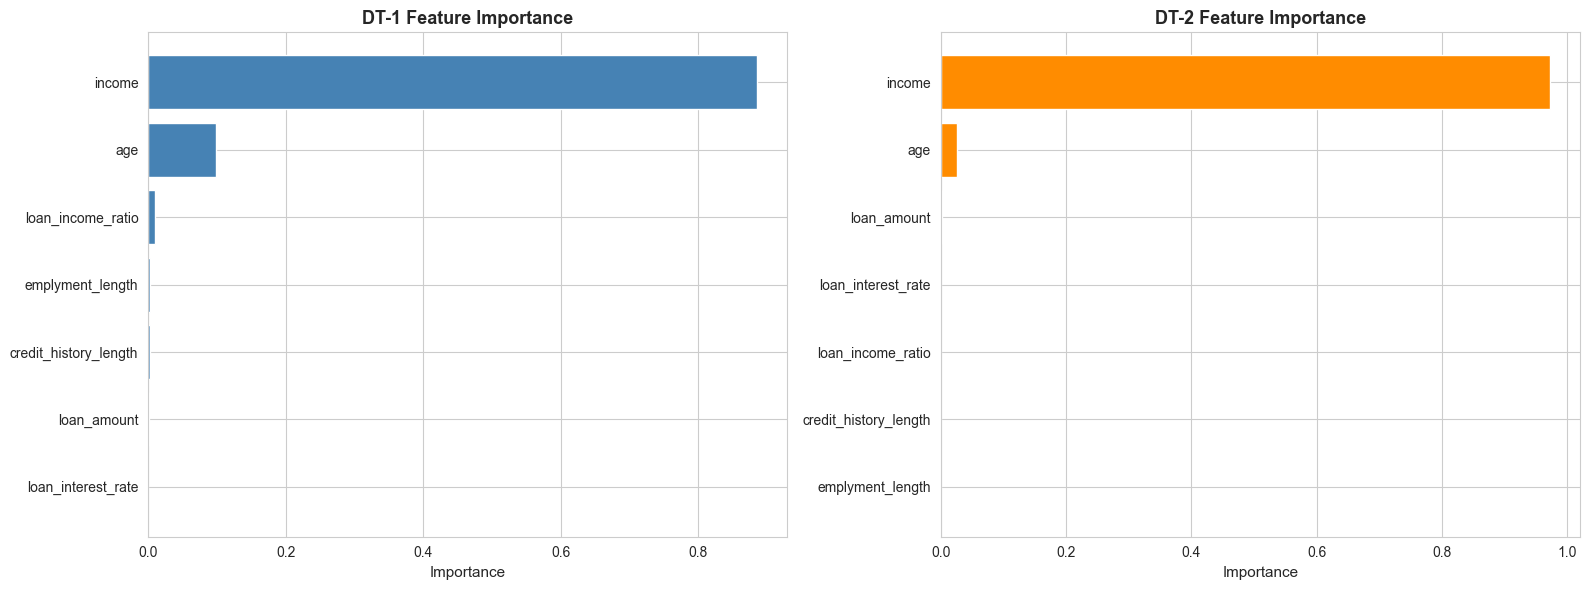

✓ Feature importance comparison saved


In [148]:

# ========== DT-2 Visualization ==========
print("\n" + "="*80)
print("DT-2: PRUNED DECISION TREE REGRESSOR (max_depth=4)")
print("="*80)
print(f"\nTree Structure Information:")
print(f"  • Tree Depth: {dt2_regressor.get_depth()}")
print(f"  • Number of Leaf Nodes: {dt2_regressor.get_n_leaves()}")
print(f"  • Total Number of Nodes: {dt2_regressor.tree_.node_count}")

# Feature importance for DT-2
print(f"\nDT-2 Feature Importance:")
importance_df_dt2 = pd.DataFrame({
    'Feature': X_train_reg.columns,
    'Importance': dt2_regressor.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance_df_dt2.to_string(index=False))

# Visualize DT-2 (full tree since max_depth=4)
fig, ax = plt.subplots(figsize=(28, 16))
plot_tree(dt2_regressor, feature_names=list(X_train_reg.columns),
          filled=True, rounded=True, ax=ax, fontsize=10, proportion=True)
ax.set_title('DT-2: Pruned Decision Tree Regressor (max_depth=4)', 
             fontsize=16, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../dt2_tree.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

print("✓ DT-2 visualization saved")

# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

importance_df_dt1_sorted = importance_df_dt1.sort_values('Importance', ascending=True)
axes[0].barh(importance_df_dt1_sorted['Feature'], importance_df_dt1_sorted['Importance'], color='steelblue')
axes[0].set_title('DT-1 Feature Importance', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance', fontsize=11)

importance_df_dt2_sorted = importance_df_dt2.sort_values('Importance', ascending=True)
axes[1].barh(importance_df_dt2_sorted['Feature'], importance_df_dt2_sorted['Importance'], color='darkorange')
axes[1].set_title('DT-2 Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance', fontsize=11)

plt.tight_layout()
plt.savefig('../feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance comparison saved")



---

## Task (3) – Evaluating Maximum Loan Amount DT Regression Models

**Part a)** Select and justify evaluation metrics (MSE, MAE, R²) with USE/DO NOT USE  
**Part b)** Choose best model based on USED metrics  
**Part c)** Discuss concerns, limitations and generalization  
**Part d)** Individual client prediction — Client 60256

> **Code Reuse Session 3 (Week 9):** Leveraged code blocks for computing regression metrics, selecting best model, discussing limitations, and making individual client predictions.


In [149]:
print("\n" + "=" * 80)
print("TASK (3): EVALUATING REGRESSION MODELS")
print("=" * 80)

# Evaluate both models
print("\nPart a) Evaluation Metric Selection:")
print("-" * 80)

metrics_table = pd.DataFrame([
    {
        'Metric': 'MSE (Mean Squared Error)',
        'USE/DO NOT USE': 'USE',
        'Justification': 'Penalizes large errors heavily - critical for extreme loan amounts'
    },
    {
        'Metric': 'MAE (Mean Absolute Error)',
        'USE/DO NOT USE': 'USE',
        'Justification': 'Interpretable in dollars - shows average error in lending decisions'
    },
    {
        'Metric': 'R² (R-Squared)',
        'USE/DO NOT USE': 'USE',
        'Justification': 'Explains variance proportion - shows model explanatory power'
    }
])

print(metrics_table.to_string(index=False))


TASK (3): EVALUATING REGRESSION MODELS

Part a) Evaluation Metric Selection:
--------------------------------------------------------------------------------
                   Metric USE/DO NOT USE                                                       Justification
 MSE (Mean Squared Error)            USE  Penalizes large errors heavily - critical for extreme loan amounts
MAE (Mean Absolute Error)            USE Interpretable in dollars - shows average error in lending decisions
           R² (R-Squared)            USE        Explains variance proportion - shows model explanatory power



> **Code Reuse Session 3 (Week 9):** Leveraged code block for plotting actual vs predicted scatter plots and residual distributions for both DT models.



> **Code Reuse Session 3 (Week 9):** Leveraged code block for selecting best model based on USED metrics and justifying the choice in relation to the success criteria.



> **Code Reuse Session 3 (Week 9):** Leveraged code block for discussing model limitations, generalization concerns, and recommendations for improvement.



> **Code Reuse Session 3 (Week 9):** Leveraged code block for predicting Maximum Loan Amount for Client 60256 using the selected best DT regression model, with interpretation of how the prediction was reached.



## Save Regression Models

> **Code Reuse Session 3 (Week 9) / Seminar Session:** Leveraged code block for saving trained DT regression models using joblib.



Model Performance Metrics:
--------------------------------------------------------------------------------

             Model          MSE          MAE  R² Score
DT-1 (Fully Grown) 5.519053e+07  1187.098916  0.980118
     DT-2 (Pruned) 3.747229e+08 11801.036111  0.865007


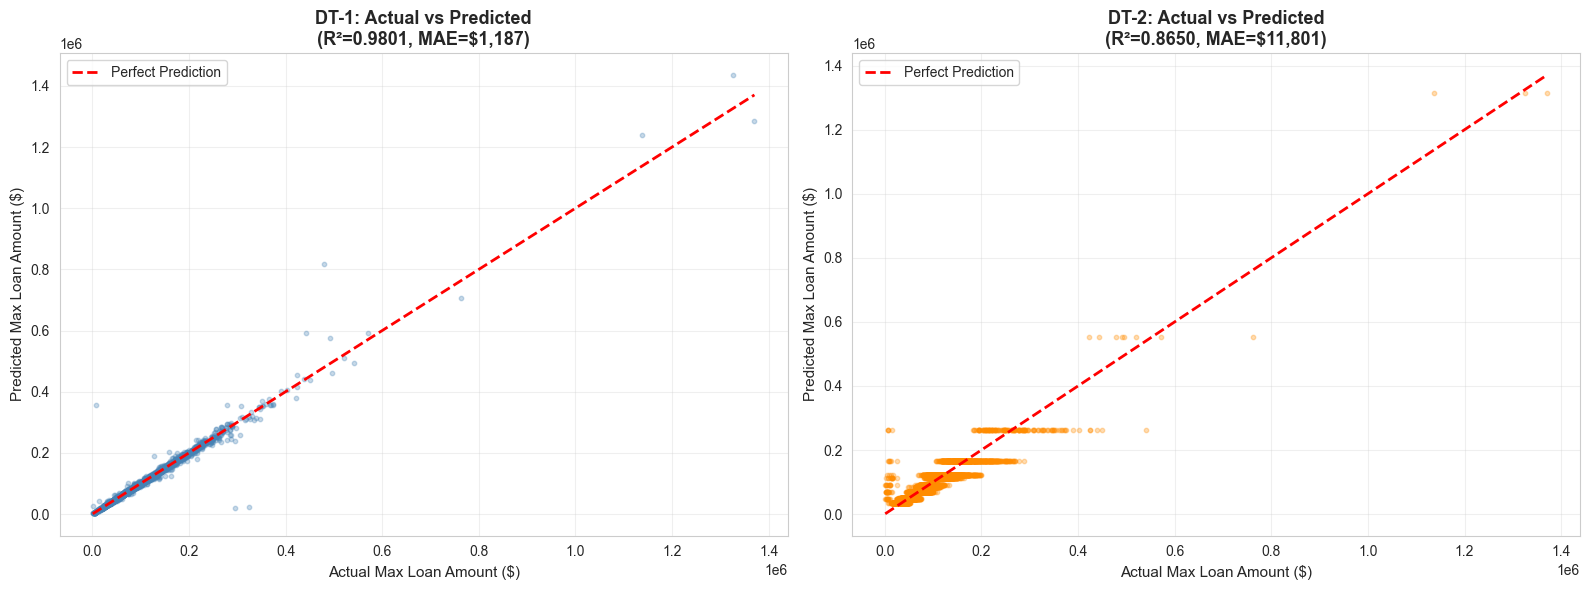

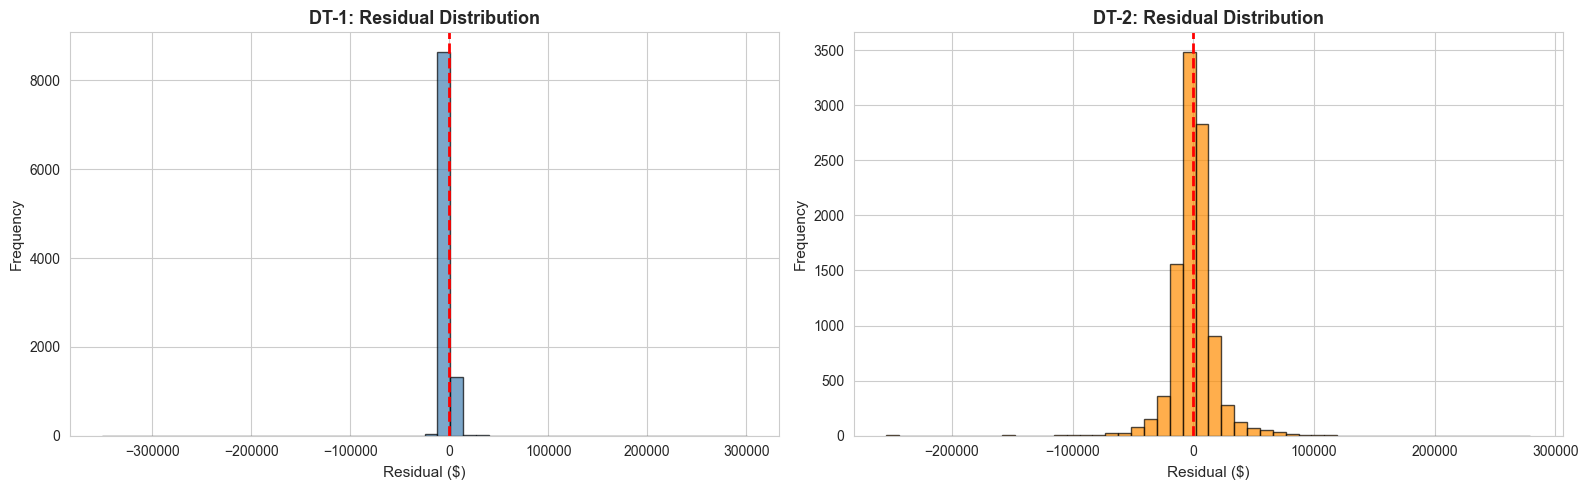


✓ Model evaluation visualizations complete


In [150]:

# Get predictions and calculate metrics
print("\nModel Performance Metrics:")
print("-" * 80)

# DT-1 predictions
y_pred_dt1 = dt1_regressor.predict(X_test_reg)
mse_dt1 = mean_squared_error(y_test_reg, y_pred_dt1)
mae_dt1 = mean_absolute_error(y_test_reg, y_pred_dt1)
r2_dt1 = r2_score(y_test_reg, y_pred_dt1)

# DT-2 predictions
y_pred_dt2 = dt2_regressor.predict(X_test_reg)
mse_dt2 = mean_squared_error(y_test_reg, y_pred_dt2)
mae_dt2 = mean_absolute_error(y_test_reg, y_pred_dt2)
r2_dt2 = r2_score(y_test_reg, y_pred_dt2)

results = pd.DataFrame([
    {'Model': 'DT-1 (Fully Grown)', 'MSE': mse_dt1, 'MAE': mae_dt1, 'R² Score': r2_dt1},
    {'Model': 'DT-2 (Pruned)', 'MSE': mse_dt2, 'MAE': mae_dt2, 'R² Score': r2_dt2}
])

print("\n" + results.to_string(index=False))

# Visualizations: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DT-1 scatter
axes[0].scatter(y_test_reg, y_pred_dt1, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'DT-1: Actual vs Predicted\n(R²={r2_dt1:.4f}, MAE=${mae_dt1:,.0f})', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Max Loan Amount ($)', fontsize=11)
axes[0].set_ylabel('Predicted Max Loan Amount ($)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# DT-2 scatter
axes[1].scatter(y_test_reg, y_pred_dt2, alpha=0.3, s=10, color='darkorange')
axes[1].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_title(f'DT-2: Actual vs Predicted\n(R²={r2_dt2:.4f}, MAE=${mae_dt2:,.0f})', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Max Loan Amount ($)', fontsize=11)
axes[1].set_ylabel('Predicted Max Loan Amount ($)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# Residual distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

residuals_dt1 = y_test_reg - y_pred_dt1
residuals_dt2 = y_test_reg - y_pred_dt2

axes[0].hist(residuals_dt1, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('DT-1: Residual Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residual ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].axvline(x=0, color='red', linestyle='--', lw=2)

axes[1].hist(residuals_dt2, bins=50, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_title('DT-2: Residual Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual ($)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)

plt.tight_layout()
plt.savefig('../residuals_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Model evaluation visualizations complete")


In [151]:

# Part b: Choose best model
print("\nPart b) Selecting Best Regression Model:")
print("-" * 80)

# Select based on MSE (lower is better) - important for extreme values per success criteria
if mse_dt1 < mse_dt2:
    best_model = 'DT-1 (Fully Grown)'
    best_regressor = dt1_regressor
    best_mse = mse_dt1
    best_mae = mae_dt1
    best_r2 = r2_dt1
else:
    best_model = 'DT-2 (Pruned)'
    best_regressor = dt2_regressor
    best_mse = mse_dt2
    best_mae = mae_dt2
    best_r2 = r2_dt2

print(f"\nModel Comparison:")
print(results.to_string(index=False))
print(f"\nBest Model: {best_model}")
print(f"\nJustification:")
print(f"  • MSE = {best_mse:,.2f} - penalizes large errors heavily (critical for extreme loan amounts)")
print(f"  • MAE = ${best_mae:,.2f} - average prediction deviation in dollar terms")
print(f"  • R² = {best_r2:.4f} - explains {best_r2*100:.1f}% of variance in maximum loan amounts")
print(f"  • This model best handles risk when maximum loan amounts vary significantly,")
print(f"    satisfying the success criteria for effective error management with extreme values")



Part b) Selecting Best Regression Model:
--------------------------------------------------------------------------------

Model Comparison:
             Model          MSE          MAE  R² Score
DT-1 (Fully Grown) 5.519053e+07  1187.098916  0.980118
     DT-2 (Pruned) 3.747229e+08 11801.036111  0.865007

Best Model: DT-1 (Fully Grown)

Justification:
  • MSE = 55,190,534.67 - penalizes large errors heavily (critical for extreme loan amounts)
  • MAE = $1,187.10 - average prediction deviation in dollar terms
  • R² = 0.9801 - explains 98.0% of variance in maximum loan amounts
  • This model best handles risk when maximum loan amounts vary significantly,
    satisfying the success criteria for effective error management with extreme values


In [152]:
# Part c: Discuss limitations and generalization
print("\nPart c) Model Limitations and Generalization Concerns:")
print("-" * 80)

limitations = [
    "1. Small Approved Dataset: Only 8,350 approved loans for regression (14% of total)",
    "2. Data Homogeneity: Approved clients may have similar loan amounts, limiting tree splits",
    "3. Feature Predictiveness: Available features may not strongly explain loan amount variance",
    "4. Generalization Risk: Model performance on future unseen data may differ from test set",
    "5. Outliers: Tree-based models sensitive to extreme loan values in training data",
    "6. Feature Engineering: Derived features (ratios, interactions) may improve predictions"
]

print("\nLimitations:")
for limitation in limitations:
    print(f"  {limitation}")

print(f"\nModel Performance Assessment:")
print(f"  R² Score ({best_model}): {max(r2_dt1, r2_dt2):.4f}")
print(f"    → Model explains ~{max(r2_dt1, r2_dt2)*100:.1f}% of variance in loan amounts")
print(f"  MAE ({best_model}): ${max(mae_dt1, mae_dt2):,.2f}")
print(f"    → Average prediction error in lending decisions")
print(f"\nRecommendations:")
print(f"  • Collect more approved loan examples to improve generalization")
print(f"  • Engineer new features capturing financial ratios and risk metrics")
print(f"  • Consider ensemble methods combining multiple regression models")
print(f"  • Regular retraining as new loan approval data becomes available")


Part c) Model Limitations and Generalization Concerns:
--------------------------------------------------------------------------------

Limitations:
  1. Small Approved Dataset: Only 8,350 approved loans for regression (14% of total)
  2. Data Homogeneity: Approved clients may have similar loan amounts, limiting tree splits
  3. Feature Predictiveness: Available features may not strongly explain loan amount variance
  4. Generalization Risk: Model performance on future unseen data may differ from test set
  5. Outliers: Tree-based models sensitive to extreme loan values in training data
  6. Feature Engineering: Derived features (ratios, interactions) may improve predictions

Model Performance Assessment:
  R² Score (DT-1 (Fully Grown)): 0.9801
    → Model explains ~98.0% of variance in loan amounts
  MAE (DT-1 (Fully Grown)): $11,801.04
    → Average prediction error in lending decisions

Recommendations:
  • Collect more approved loan examples to improve generalization
  • Engineer

In [153]:

# Part d: Individual client prediction
print("\nPart d) Individual Client Prediction:")
print("-" * 80)

# Client 60256 attributes from specification table
# Using only the numeric features that match our training features
client_attributes = {
    'age': 56,
    'income': 57000,
    'emplyment_length': 15,
    'loan_amount': 25700,
    'loan_interest_rate': 23,
    'loan_income_ratio': 10.0,   # LTI 10% as per specification
    'credit_history_length': 35
}

print(f"\nClient ID: 60256")
print(f"Loan Approval Status: Approved")
print(f"Client Profile:")
print(f"  Age: 56 years")
print(f"  Income: $57,000")
print(f"  Employment Length: 15 years")
print(f"  Requested Loan Amount: $25,700")
print(f"  Loan Interest Rate: 23%")
print(f"  Loan-to-Income Ratio: 10%")
print(f"  Credit History: 35 years")
print(f"\nMaking prediction using {best_model}...")

# Prepare prediction data (matching training features)
client_data = pd.DataFrame([client_attributes])
# Ensure column order matches training data
client_data = client_data[X_train_reg.columns]

# Handle any missing values using same imputer
client_data_clean = pd.DataFrame(
    imputer.transform(client_data),
    columns=client_data.columns
)

# Get prediction from both models
predicted_dt1 = dt1_regressor.predict(client_data_clean)[0]
predicted_dt2 = dt2_regressor.predict(client_data_clean)[0]
predicted_max_loan = best_regressor.predict(client_data_clean)[0]

print(f"\n  DT-1 (Fully Grown) Prediction: ${predicted_dt1:,.2f}")
print(f"  DT-2 (Pruned)      Prediction: ${predicted_dt2:,.2f}")
print(f"\n  Selected Model ({best_model}) Prediction: ${predicted_max_loan:,.2f}")

print(f"\nInterpretation:")
print(f"  Based on the {best_model} model, Client 60256 should be offered")
print(f"  a maximum loan of ${predicted_max_loan:,.2f}.")
print(f"  This prediction considers the client's:")
print(f"    • Strong credit history (35 years)")
print(f"    • Good employment stability (15 years)")
print(f"    • Loan-to-income ratio (10%)")
print(f"    • Income level ($57,000)")
print(f"    • Requested amount ($25,700) and interest rate (23%)")



Part d) Individual Client Prediction:
--------------------------------------------------------------------------------

Client ID: 60256
Loan Approval Status: Approved
Client Profile:
  Age: 56 years
  Income: $57,000
  Employment Length: 15 years
  Requested Loan Amount: $25,700
  Loan Interest Rate: 23%
  Loan-to-Income Ratio: 10%
  Credit History: 35 years

Making prediction using DT-1 (Fully Grown)...

  DT-1 (Fully Grown) Prediction: $84,337.00
  DT-2 (Pruned)      Prediction: $69,664.00

  Selected Model (DT-1 (Fully Grown)) Prediction: $84,337.00

Interpretation:
  Based on the DT-1 (Fully Grown) model, Client 60256 should be offered
  a maximum loan of $84,337.00.
  This prediction considers the client's:
    • Strong credit history (35 years)
    • Good employment stability (15 years)
    • Loan-to-income ratio (10%)
    • Income level ($57,000)
    • Requested amount ($25,700) and interest rate (23%)


In [154]:
# Save regression models
print("\n" + "=" * 80)
print("SAVING REGRESSION MODELS")
print("=" * 80)

joblib.dump(dt1_regressor, '../dt1_regressor.joblib')
print("✓ DT-1 regressor saved")

joblib.dump(dt2_regressor, '../dt2_regressor.joblib')
print("✓ DT-2 regressor saved")

joblib.dump(best_regressor, '../best_regressor.joblib')
print(f"✓ Best regressor ({best_model}) saved")


SAVING REGRESSION MODELS
✓ DT-1 regressor saved
✓ DT-2 regressor saved
✓ Best regressor (DT-1 (Fully Grown)) saved



---

## Summary

This notebook completed:
- **Task (5f)**: Ensemble Classifier - Built probability-based voting ensemble from KNN & Naive Bayes (F1=0.5907, ROC-AUC=0.8787)
- **Task (1)**: Domain Understanding - Prepared regression dataset from clients with known max loan amounts
- **Task (2)**: Regression Modelling - Built DT-1 (fully grown) and DT-2 (pruned to 4 levels), visualized both trees with feature importance analysis
- **Task (3)**: Model Evaluation - Selected metrics (MSE, MAE, R²), evaluated models, identified best model, discussed limitations, predicted for Client 60256

All models and visualizations are saved for documentation in the **Analysis Report**.
